In [37]:
import pandas as pd 
import openpyxl
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
path = r"H:\Python\analise_dados\atv4\CD2022_Populacao_2010_Compatibilizada_20231222 (1).xlsx"

In [6]:
tabela = pd.read_excel(path, header=None)

In [7]:
tabela

,0,1,2,3,4,5,6,7
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Censo Demográfico 2022: População e Domicílios...,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,UF,COD. UF,COD. MUNIC,NOME DO MUNICÍPIO,População Município 2010\n(Sinopse),População 2010 (Alterações de Limites até 2022)1,População Censo 2022
3,NaN,RO,11,00015,Alta Floresta D'Oeste,24392,24392,21494
4,NaN,RO,11,00023,Ariquemes,90353,90353,96833
...,...,...,...,...,...,...,...,...
5572,NaN,DF,53,00108,Brasília,2570160,2572159,2817381
5573,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5574,NaN,Nota: Para o cálculo das taxas de crescimento ...,NaN,NaN,NaN,NaN,NaN,NaN
5575,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
tabela_formatada = tabela.iloc[2:5573, 1:].copy()

In [9]:
tabela_formatada.reset_index(drop=True)
tabela_formatada

,1,2,3,4,5,6,7
2,UF,COD. UF,COD. MUNIC,NOME DO MUNICÍPIO,População Município 2010\n(Sinopse),População 2010 (Alterações de Limites até 2022)1,População Censo 2022
3,RO,11,00015,Alta Floresta D'Oeste,24392,24392,21494
4,RO,11,00023,Ariquemes,90353,90353,96833
5,RO,11,00031,Cabixi,6313,6313,5351
6,RO,11,00049,Cacoal,78574,78574,86887
...,...,...,...,...,...,...,...
5568,GO,52,22005,Vianópolis,12548,12548,14956
5569,GO,52,22054,Vicentinópolis,7371,7373,8768
5570,GO,52,22203,Vila Boa,4735,4735,4215
5571,GO,52,22302,Vila Propício,5145,5145,5815


In [10]:
tabela_formatada.columns = [
    "uf",
    "cod_uf",
    "cod_municipio",
    "nome_municipio",
    "população 2010",
    "população 2010 alterações até 2021",
    "população 2022"
]

In [11]:
tabela_formatada

,uf,cod_uf,cod_municipio,nome_municipio,população 2010,população 2010 alterações até 2021,população 2022
2,UF,COD. UF,COD. MUNIC,NOME DO MUNICÍPIO,População Município 2010\n(Sinopse),População 2010 (Alterações de Limites até 2022)1,População Censo 2022
3,RO,11,00015,Alta Floresta D'Oeste,24392,24392,21494
4,RO,11,00023,Ariquemes,90353,90353,96833
5,RO,11,00031,Cabixi,6313,6313,5351
6,RO,11,00049,Cacoal,78574,78574,86887
...,...,...,...,...,...,...,...
5568,GO,52,22005,Vianópolis,12548,12548,14956
5569,GO,52,22054,Vicentinópolis,7371,7373,8768
5570,GO,52,22203,Vila Boa,4735,4735,4215
5571,GO,52,22302,Vila Propício,5145,5145,5815


In [12]:
pop_estado = (
    tabela_formatada.groupby(["cod_uf", "uf"], as_index=False)
      .agg(
          populacao_2010=("população 2010", "sum"),
          populacao_2022=("população 2022", "sum"),
      )
)

In [13]:
pop_estado

,cod_uf,uf,populacao_2010,populacao_2022
0,11,RO,1562409,1581196
1,12,AC,733559,830018
2,13,AM,3483985,3941613
3,14,RR,450479,636707
4,15,PA,7581051,8120131
5,16,AP,669526,733759
6,17,TO,1383445,1511460
7,21,MA,6574789,6776699
8,22,PI,3118360,3271199
9,23,CE,8452381,8794957


In [14]:
pop_estado = pop_estado.iloc[0:26, 0:].copy()


In [15]:
pop_estado

,cod_uf,uf,populacao_2010,populacao_2022
0,11,RO,1562409,1581196
1,12,AC,733559,830018
2,13,AM,3483985,3941613
3,14,RR,450479,636707
4,15,PA,7581051,8120131
5,16,AP,669526,733759
6,17,TO,1383445,1511460
7,21,MA,6574789,6776699
8,22,PI,3118360,3271199
9,23,CE,8452381,8794957


In [17]:
pop_estado.to_csv(r"H:\Python\analise_dados\atv4\populacao.csv", sep =";")

In [18]:
path2 = r'H:\Python\analise_dados\atv4\populacao.csv'

In [22]:
tabela2 = pd.read_csv(path2, sep=";")

In [24]:
tabela2 = tabela2.iloc[1:25, 1:]

In [25]:
tabela2

,cod_uf,uf,populacao_2010,populacao_2022
1,12,AC,733559,830018
2,13,AM,3483985,3941613
3,14,RR,450479,636707
4,15,PA,7581051,8120131
5,16,AP,669526,733759
6,17,TO,1383445,1511460
7,21,MA,6574789,6776699
8,22,PI,3118360,3271199
9,23,CE,8452381,8794957
10,24,RN,3168027,3302729


In [26]:
tabela2["diferença"] = tabela2["populacao_2022"] - tabela2['populacao_2010']

In [27]:
tabela2

,cod_uf,uf,populacao_2010,populacao_2022,diferença
1,12,AC,733559,830018,96459
2,13,AM,3483985,3941613,457628
3,14,RR,450479,636707,186228
4,15,PA,7581051,8120131,539080
5,16,AP,669526,733759,64233
6,17,TO,1383445,1511460,128015
7,21,MA,6574789,6776699,201910
8,22,PI,3118360,3271199,152839
9,23,CE,8452381,8794957,342576
10,24,RN,3168027,3302729,134702


In [29]:
tabela2 = tabela2.sort_values("diferença", ascending=False)

In [30]:
tabela2

,cod_uf,uf,populacao_2010,populacao_2022,diferença
19,35,SP,41262199,44411238,3149039
21,42,SC,6248436,7610361,1361925
20,41,PR,10444526,11444380,999854
16,31,MG,19597330,20539989,942659
24,51,MT,3035122,3658649,623527
4,15,PA,7581051,8120131,539080
2,13,AM,3483985,3941613,457628
9,23,CE,8452381,8794957,342576
17,32,ES,3514952,3833712,318760
23,50,MS,2449024,2757013,307989


In [32]:
populacao_com_diferenca = tabela2.to_csv(r"H:\Python\analise_dados\atv4\populacao_com_diferenca.csv", sep =";")

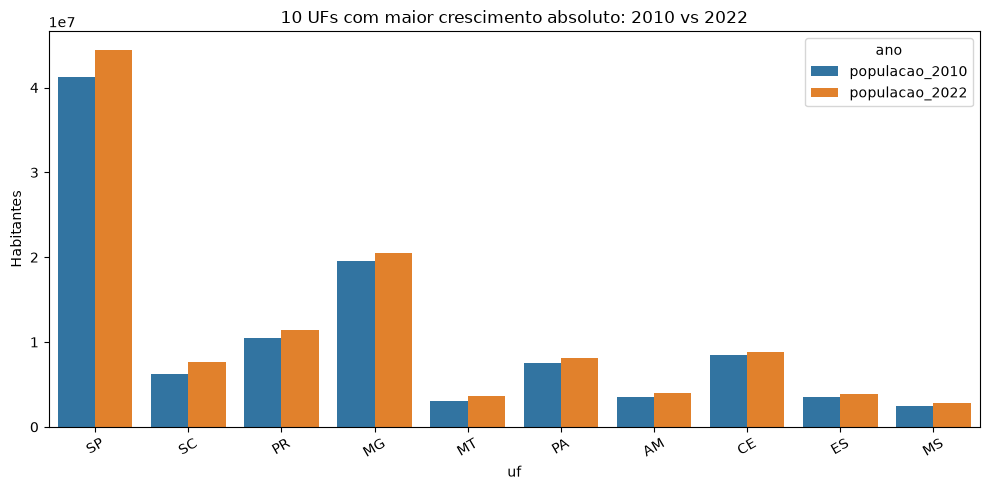

In [39]:
top = tabela2.head(10).melt(
    id_vars="uf",
    value_vars=["populacao_2010", "populacao_2022"],
    var_name="ano",
    value_name="populacao",
)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=top, x="uf", y="populacao", hue="ano", ax=ax)
ax.set_title("10 UFs com maior crescimento absoluto: 2010 vs 2022")
ax.set_ylabel("Habitantes")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()